# Brain MRI pathology synthesis (exploratory notebook)

Author: Oluwasegun Isaac Oyekunle (DATICAN Scholar).

**Attribution.** The k-space preprocessing, the helper functions in the *Needed Function* cell, and the Gaussian-process reconstruction section at the end of this notebook are adapted from the KspaceMRIBO code released with: Xu, Farris, Anderson, Zhang and Brown, *Bayesian reconstruction of magnetic resonance images using Gaussian processes* (https://github.com/yihonglilyxu/KspaceMRIBO). The lesion-synthesis cells in the middle of the notebook are my own work.

No image data is stored in this repository; see the README for how to supply the input volume.

In [ ]:
pip install torch torchvision matplotlib numpy h5py fastmri nibabel scikit-image os-sys

In [ ]:
pip install fastmri

In [ ]:
!pip install nibabel

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import torch
import torchvision

import matplotlib as m
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
import h5py

import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
from fastmri.math import complex_abs

import nibabel as nib
import skimage
from skimage.transform import resize
os.chdir('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src')
from utils.loss import mse,nmse,psnr,ssim

import math
import time

imgsz = 256
w = 48

## Needed Function ##



In [ ]:
######### Reconstruction Function #########

def zerofill_samp(img1_k,ind):
  img_r = fastmri.complex_abs(ifft2c_new(img1_k)).view(-1,1)
  img_r = img_r.reshape(imgsz,imgsz)
  pixnum = len(ind)
  img1_k_ = img1_k[w:imgsz-w,w:imgsz-w,:]
  picked_r = img1_k_[:,:,0].reshape(-1,1)
  picked_i = img1_k_[:,:,1].reshape(-1,1)

  for i in range((imgsz-2*w)**2):
    if i not in ind:
      picked_r[i,0] = 0
      picked_i[i,0] = 0

  picked_r = picked_r.reshape(imgsz-2*w,imgsz-2*w)
  picked_i = picked_i.reshape(imgsz-2*w,imgsz-2*w)

  picked_k = torch.stack([picked_r,picked_i],dim = 2)

  whole_k = torch.zeros(imgsz,imgsz,2)
  whole_k[w:imgsz-w,w:imgsz-w,:] = picked_k
  rcon = fastmri.complex_abs(ifft2c_new(whole_k))

  nmse_ =  nmse(img_r.numpy(),rcon.numpy())
  ssim_ =  ssim(img_r.numpy(),rcon.numpy())
  psnr_ = psnr(img_r.numpy(),rcon.numpy())


  return rcon,nmse_,ssim_,psnr_


def bayesian_stat_r_nor(img_k1,ind,sig,realcov_,imagcov_,ind_previous = None):
  #img_k1 size: cropped sized (imgsz-2*w, imgsz-2*w)

  pixnum = len(ind)

  realcovmat = realcov_[ind,:][:,ind] + sig*torch.eye(pixnum)
  imagcovmat = imagcov_[ind,:][:,ind] + sig*torch.eye(pixnum)

  realcovvec = realcov_[:,ind]
  imagcovvec = imagcov_[:,ind]

  for i in range(len(ind)):
    realcovmat[i,i] = realvar[ind[i]] + sig
    imagcovmat[i,i] = imagvar[ind[i]] + sig
    realcovvec[ind[i],i] = realvar[ind[i]]
    imagcovvec[ind[i],i] = imagvar[ind[i]]

  rmean = torch.matmul(realcovvec,torch.matmul(torch.inverse(realcovmat),(img_k1[:,:,0]/magmean-realmean).view(-1,1)[ind])) + realmean.view(-1,1)
  imean = torch.matmul(imagcovvec,torch.matmul(torch.inverse(imagcovmat),(img_k1[:,:,1]/magmean-imagmean).view(-1,1)[ind])) + imagmean.view(-1,1)

  rmean[ind] = ((img_k1[:,:,0]/magmean).reshape((imgsz-2*w)**2,1))[ind]
  imean[ind] = ((img_k1[:,:,1]/magmean).reshape((imgsz-2*w)**2,1))[ind]

  rvar = realvar - torch.sum(torch.matmul(realcov[:,ind],torch.inverse(realcovmat))*realcov[:,ind],1) + sig
  ivar = imagvar - torch.sum(torch.matmul(imagcov[:,ind],torch.inverse(imagcovmat))*imagcov[:,ind],1) + sig

  if ind_previous != None:
    ind = torch.cat([ind_previous,ind])


  kmean = torch.stack([(rmean).reshape(imgsz-2*w,imgsz-2*w)*magmean,\
                         (imean).reshape(imgsz-2*w,imgsz-2*w)*magmean],dim=2)


  rmean = rmean.reshape(imgsz-2*w,imgsz-2*w)
  imean = imean.reshape(imgsz-2*w,imgsz-2*w)

  return rmean,imean,kmean,rvar,ivar



def bayesian_mean_samp_nor(img1_k,ind,lamb):
  pixnum = len(ind)

  img1_r = fastmri.complex_abs(ifft2c_new(img1_k)).view(-1,1)
  img1_r = img1_r.reshape(imgsz,imgsz)
  img1_k_ = (img1_k[w:imgsz-w,:,:])[:,w:imgsz-w,:]

  realcovmat = realcov[ind,:][:,ind] + lamb*torch.eye(pixnum)
  imagcovmat = imagcov[ind,:][:,ind] + lamb*torch.eye(pixnum)

  realcovvec = realcov[:,ind]
  imagcovvec = imagcov[:,ind]
  rmean = torch.matmul(realcovvec,torch.matmul(torch.inverse(realcovmat),(img1_k_[:,:,0]/magmean-realmean).view(-1,1)[ind])) + realmean.reshape(-1,1)
  imean = torch.matmul(imagcovvec,torch.matmul(torch.inverse(imagcovmat),(img1_k_[:,:,1]/magmean-imagmean).view(-1,1)[ind])) + imagmean.reshape(-1,1)


  rmean[ind] = ((img1_k_[:,:,0]/magmean).reshape((imgsz-2*w)**2,1))[ind]
  imean[ind] = ((img1_k_[:,:,1]/magmean).reshape((imgsz-2*w)**2,1))[ind]

  kmean = torch.stack([(rmean).reshape(imgsz-2*w,imgsz-2*w)*magmean,\
                         (imean).reshape(imgsz-2*w,imgsz-2*w)*magmean],dim=2)

  kmean_whole = torch.zeros(imgsz,imgsz,2)
  kmean_whole[w:imgsz-w,w:imgsz-w,:] = kmean
  bayesian_mean = fastmri.complex_abs(ifft2c_new(kmean_whole))

  nmse_ =  nmse(img1_r.numpy(),bayesian_mean.numpy())
  ssim_ =  ssim(img1_r.numpy(),bayesian_mean.numpy())
  psnr_ = psnr(img1_r.numpy(),bayesian_mean.numpy())

  return bayesian_mean,nmse_,ssim_,psnr_


######### Geometric Function #########
def mask_of_r(imgsz,r):
  mask = torch.zeros(imgsz,imgsz)

  for i in range(imgsz):
    for j in range(imgsz):
      i_ = i - (imgsz-1)/2
      j_ = j - (imgsz-1)/2

      if (i_**2+j_**2)**0.5 >= r and (i_**2+j_**2)**0.5 < r+1:
  #  if np.round((i_**2+j_**2)**0.5) == r:
        mask[i,j] = 1

  return mask

def mask_in_r(imgsz,r):
  mask = torch.zeros(imgsz,imgsz)

  for i in range(imgsz):
    for j in range(imgsz):
      i_ = i - (imgsz-1)/2
      j_ = j - (imgsz-1)/2

      if (i_**2+j_**2)**0.5 <= r:
        mask[i,j] = 1
  return mask

def mask_of_phi(imgsz,r_low,r_high,phi_low,phi_up):
  mask = torch.zeros(imgsz,imgsz)
  for i in range(imgsz):
    for j in range(imgsz):
      i_ = torch.tensor([(imgsz-1-i) - (imgsz - 1)/2])
      j_ = torch.tensor([j - (imgsz - 1)/2])
      if torch.sqrt(i_**2+j_**2) > r_low and torch.sqrt(i_**2+j_**2) <= r_high:
        if phi_low <= (torch.atan(i_/j_)) and (torch.atan(i_/j_)) < phi_up:
          mask[i,j] = 1

  return mask

def mask_of_r_order(imgsz,rlist):
  mask = torch.zeros(imgsz,imgsz).view(-1)
  ratio = torch.zeros(len(rlist))
  n = 0
  for i in rlist:
    mask[r_dic[int(i)]] = 1
    ratio[n] = torch.sum(mask == 1)/256**2
    n += 1

  mask = mask.reshape(imgsz,imgsz)

  return mask, ratio

######### Find the optimal sampling path of a single image #########
def GPR_cir_nor(img_k,round,thre,mode = None):
  #img_k: original size k-space image
  img_r = fastmri.complex_abs(ifft2c_new(img_k)).view(-1,1)
  img_r = img_r.reshape(imgsz,imgsz)
  #crop the k-space image
  img_k_ = (img_k[w:imgsz-w,:,:])[:,w:imgsz-w,:]

  error_whole = torch.zeros(round,imgsz-2*w,imgsz-2*w)
  errormag_list = torch.zeros(round,(imgsz - 2*w)//2+1)
  results_list = torch.zeros(round, 4)
  #img_list = torch.zeros(round,imgsz,imgsz)

  r_list = []

  realcov_ = torch.clone(realcov)
  imagcov_ = torch.clone(imagcov)
  realmean_ = torch.clone(realmean)
  imagmean_ = torch.clone(imagmean)

  realvar_ = torch.clone(realvar)
  imagvar_ = torch.clone(imagvar)

  if mode == 'pix_var':
    realvar_all = torch.zeros((imgsz-2*w)**2,round)
    imagvar_all = torch.zeros((imgsz-2*w)**2,round)
    magerr_all = torch.zeros((imgsz-2*w)**2,round)
  else:
    realvar_all = 0
    imagvar_all = 0
    magerr_all = 0


  for i in range(round):

    mag = torch.sqrt(realmean_**2 + imagmean_**2)
    if mode == 'pix_var':
      realvar_all[:,i] = realvar_
      imagvar_all[:,i] = imagvar_

    realvar_[realvar_ < 0] = sig
    imagvar_[imagvar_ < 0] = sig

    errorreal = realvar_**0.5
    errorimag = imagvar_**0.5

    errormag = torch.sqrt((realmean_.view(-1))**2*errorreal**2+(imagmean_.view(-1))**2*errorimag**2)/(mag/magmean).view(-1)
    #errormag = torch.sqrt((realmean_.view(-1))**2*errorreal**2+(imagmean_.view(-1))**2*errorimag**2)/(mag).view(-1)
    errormag[(mag*magmean).view(-1) == 0] = 0

    error_whole[i,:,:] = errormag.reshape(160,160)
    if mode == 'pix_var':
      magerr_all[:,i] = errormag

  #calculate the mean magnitude error and find the maximum position to sample

    errormagmean = magerror_rrank(imgsz,w,errormag)
    errormag_list[i,:] = errormagmean

    sorted_error, ind_r = torch.sort(errormagmean, descending = True)
    for ind in ind_r:
      if ind not in r_list:
        r_ind = ind
        break

    #r_ind = torch.argmax(errormagmean)

    ind0 = torch.from_numpy(r_dic[r_ind.item()])

    r_list.append(r_ind)
    print('round:',i,',chosen r position:',r_ind.item())


    #update distribution
    if i == 0:

      realmean_,imagmean_,kmean,realvar_,imagvar_ = bayesian_stat_r_nor(img_k_,ind0,sig,realcov_,imagcov_,ind_previous = None)
      ind_list = ind0

    else:
      ind_list = torch.cat([ind_list,ind0])
      if i != round - 1:
          realmean_,imagmean_,kmean,realvar_,imagvar_  = bayesian_stat_r_nor(img_k_,ind_list,sig,realcov_,imagcov_,ind_previous = None)
 #kmean_:already denormolized, real&imagmean: normalized and divided by sqrt(real^2+imag^2)


    kmean_whole = torch.zeros(imgsz,imgsz,2)
    kmean_whole[w:imgsz-w,w:imgsz-w,:] = kmean


  return r_list, errormag_list, error_whole


##make r index dictionary
r_dic = {}

rlist = np.linspace(0,int((imgsz-2*w)/2),int((imgsz-2*w)/2)+1,dtype=int)
indlist = np.linspace(0,(imgsz-2*w)**2-1,(imgsz-2*w)**2,dtype=int)
for i in rlist:
  mask = mask_of_r(imgsz-2*w,i)
  r_dic[i] = indlist[mask.view(-1) == 1]


def magerror_rrank(imgsz,w,errormag):
  rlist = np.linspace(0,int((imgsz-2*w)/2),int((imgsz-2*w)/2+1),dtype=int)
  errorlist = torch.zeros(int((imgsz-2*w)/2)+1)
  start = time.time()

  for i in rlist:
    errorlist[i] = torch.mean(errormag.view(-1)[r_dic[i]])

  end = time.time()
  return errorlist

def mask_larger(imgsz,w,mask):
  mask_ = torch.zeros(256,256)
  mask_[w:imgsz-w,w:imgsz-w] = mask
  return mask_


def ind_to_ij(ind):
  return ind//(imgsz-2*w),ind%(imgsz-2*w)

def ind_to_xy(ind):
  i = (ind//(imgsz-2*w))
  j = (ind%(imgsz-2*w))
  y = (imgsz-2*w-1-i) - (imgsz-2*w - 1)/2
  x = j - (imgsz-2*w - 1)/2
  return x,y

def ij_to_phi(i,j):
  i_ = (imgsz-2*w-1-i) - (imgsz-2*w - 1)/2
  j_ = j - (imgsz-2*w - 1)/2
  #phi: size(1,#pixels)
  return torch.atan2(i_,j_)

def xy_to_ind(x,y):
  i = (imgsz-2*w-1) - (imgsz-2*w - 1)/2 - y
  j = x + (imgsz-2*w - 1)/2
  ind = i*(imgsz-2*w) + j
  return ind

def true_her(x,y):
    return 1-x, -1-y


##Image Preprocessing##




**Here we present the method to extract the real-space MR images in NIFTI format, resize it to 256*256 pixels, normalize,and transform the real-space to k-space data.** \
1. **Given a 3D MR image from IXI public dataset, we read the image data, get the 2D axial image slice,and get the output as numpy array.**

The size of the MR image is: (260, 311, 260)
The voxel size of the MR image is: (0.7, 0.7, 0.7)
The 2D MR image data is from the first and second axis (Axial View)
The slice index chosen is 132


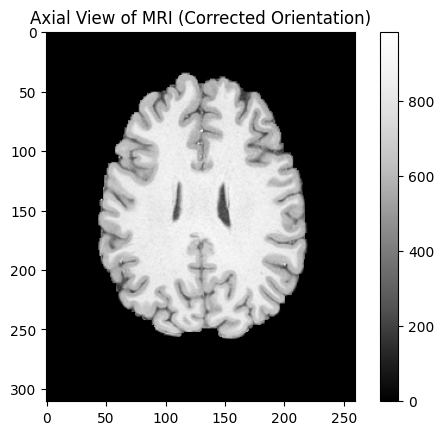

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load MRI data
file_path = '/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/MRI_data/T1w_acpc_dc_restore_brain.nii'
im = nib.load(file_path).get_fdata()
vx_size = nib.load(file_path).header.get_zooms()

# Print image details
print('The size of the MR image is:', im.shape)
print('The voxel size of the MR image is:', vx_size)
print('The 2D MR image data is from the first and second axis (Axial View)')

# Select an axial slice
i = 132
im_axial = im[:, :, i]  # Extract along the axial plane

# Apply flipping and rotation
im_axial = np.flipud(im_axial)  # Flip vertically
im_axial = np.rot90(im_axial, k=1)  # Rotate 90 degrees counterclockwise

print('The slice index chosen is', i)

# Display the corrected image
plt.imshow(im_axial, cmap='Greys_r')
plt.colorbar()
plt.title('Axial View of MRI (Corrected Orientation)')
plt.show()

2. **We normalize the image and resize it to 256*256 array.**

> Since the pixel size of the original image is (1.2000,0.9375), while the images size is (256,150). We first reshaped the normalized image into (250,200) and zero-padded the image into (256,256).




Image shape: (260, 311, 260)


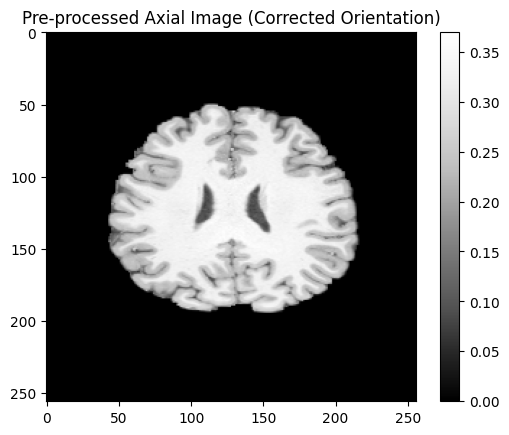

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

# Normalize the image
im /= np.max(im)
im0 = np.copy(im)

# Check image shape
print("Image shape:", im.shape)

# Select an axial slice if it's 3D
if len(im.shape) == 3:
    axial_index = im.shape[2] // 2  # Choose the middle slice
    im = im[:, :, axial_index]  # Extract a 2D axial slice
else:
    print("Warning: Image is already 2D. Skipping slice selection.")

# Apply flipping and rotation to correct orientation
im = np.flipud(im)  # Flip vertically
im = np.rot90(im, k=1)  # Rotate 90 degrees counterclockwise

# Resize and reformat
imgsz = 256  # Define the target image size
im = resize(im, (200, imgsz))
im_final = np.zeros((imgsz, imgsz))
im_final[28:28+200, :] = im  # Correct placement for axial view
im = np.copy(im_final)

# Display
plt.imshow(im, cmap='Greys_r')
plt.colorbar()
plt.title('Pre-processed Axial Image (Corrected Orientation)')
plt.show()

3. **Apply Fast Fourier Transform (FFT) to get the ground truth *k*-space image.**

Original image shape: (256, 256)
Processed image shape: (256, 256)
The size of input k-space image is: torch.Size([256, 256, 2])


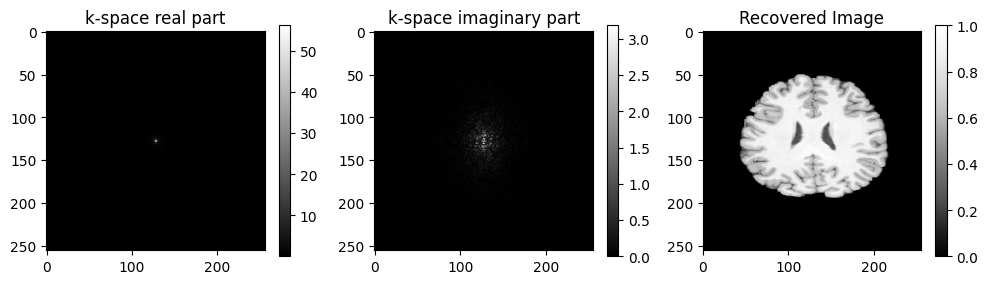

----------------------------------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.transform import resize
import fastmri

# Ensure image normalization
im /= np.max(im)

# Check shape and reshape properly
print("Original image shape:", im.shape)

if len(im.shape) == 3:
    axial_index = im.shape[2] // 2  # Choose the middle slice
    im = im[:, :, axial_index]  # Extract a 2D axial slice
    im = np.flipud(im)  # Flip vertically
    im = np.rot90(im, k=1)  # Rotate 90 degrees counterclockwise
else:
    print("Warning: Image is already 2D. Skipping slice selection.")

# Resize and reformat
imgsz = 256  # Define image size
im = resize(im, (imgsz, imgsz))
print("Processed image shape:", im.shape)

# Reshape for processing
im = im.reshape((imgsz, imgsz, 1))

# Convert to k-space format
im_k = torch.from_numpy(np.concatenate((im, np.zeros_like(im)), axis=2)).float()
print('The size of input k-space image is:', im_k.size())

# Perform Fourier Transform
im_k = fastmri.fft2c(im_k)  # Assuming fft2c_new -> fastmri.fft2c

# Recover real-space image from fully sampled k-space
origin_im = fastmri.complex_abs(fastmri.ifft2c(im_k)).numpy()

# Display k-space and recovered image
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

fig0 = axes[0].imshow(abs(im_k[:, :, 0]), cmap='gray')
plt.colorbar(fig0, ax=axes[0])
axes[0].set_title('k-space real part')

fig1 = axes[1].imshow(abs(im_k[:, :, 1]), cmap='gray')
plt.colorbar(fig1, ax=axes[1])
axes[1].set_title('k-space imaginary part')

fig2 = axes[2].imshow(origin_im, cmap='Greys_r')
plt.colorbar(fig2, ax=axes[2])
axes[2].set_title('Recovered Image')

plt.show()

print('--' * 50)

The size of the MR image is: (260, 311, 260)
The voxel size of the MR image is: (0.7, 0.7, 0.7)
Extracting 2D MR image from the first and third axis (Axial View)
The slice index chosen is 132


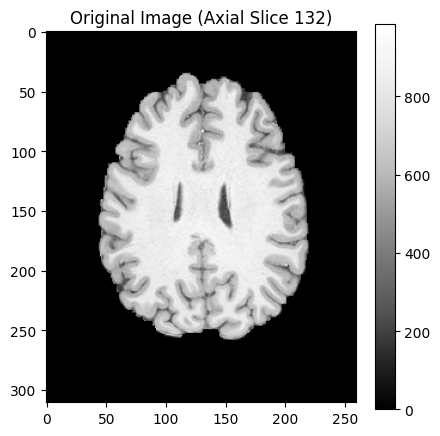

The size of input k-space image is: torch.Size([256, 256, 2])


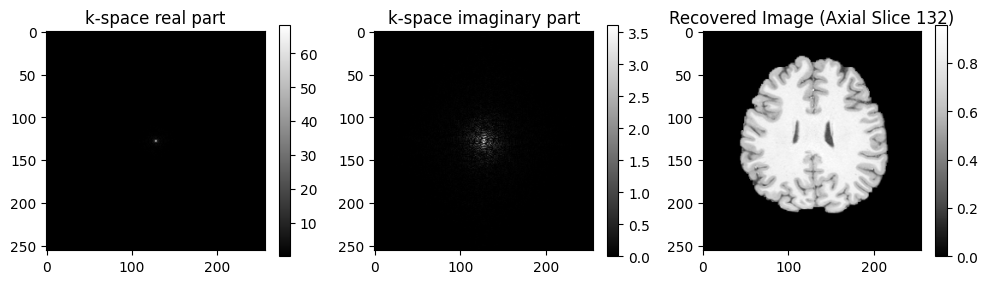

----------------------------------------------------------------------------------------------------


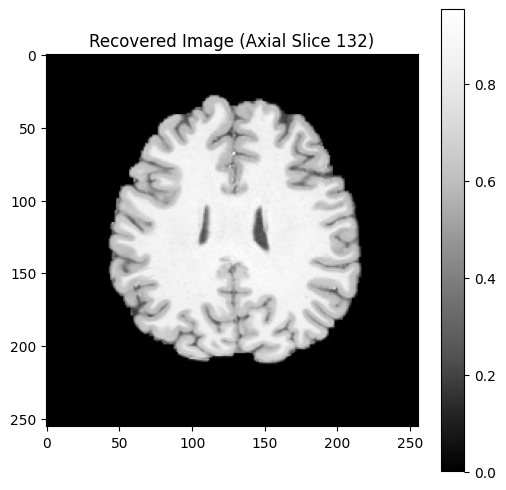

In [ ]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
from skimage.transform import resize
import fastmri

# Define constants
imgsz = 256  # Standard image size for processing

# Load MRI data
file_path = '/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/MRI_data/T1w_acpc_dc_restore_brain.nii'
im = nib.load(file_path).get_fdata()
vx_size = nib.load(file_path).header.get_zooms()

print('The size of the MR image is:', im.shape)
print('The voxel size of the MR image is:', vx_size)
print('Extracting 2D MR image from the first and third axis (Axial View)')

# **Choose specific axial slice (132)**
slice_indices = [132]
recovered_images = []

for i in slice_indices:
    # Extract **AXIAL** slice
    im_slice = im[:, :, i]

    # Ensure correct axial orientation
    im_slice = np.flipud(im_slice)  # Flip vertically
    im_slice = np.rot90(im_slice, k=1)  # Rotate 90 degrees counterclockwise

    print(f'The slice index chosen is {i}')

    # Display the original axial slice
    plt.figure(figsize=(5, 5))
    plt.imshow(im_slice, cmap='Greys_r')
    plt.colorbar()
    plt.title(f'Original Image (Axial Slice {i})')
    plt.show()

    # Normalize and preprocess the slice
    im_slice /= np.max(im_slice)
    im_resized = resize(im_slice, (imgsz, imgsz))
    im_processed = im_resized.reshape((imgsz, imgsz, 1))

    # Convert to k-space format
    im_k = torch.from_numpy(np.concatenate((im_processed, np.zeros_like(im_processed)), axis=2)).float()
    print('The size of input k-space image is:', im_k.size())

    # Perform Fourier Transform
    im_k = fastmri.fft2c(im_k)  # Using `fastmri.fft2c`

    # Recover real-space image from fully sampled k-space
    origin_im = fastmri.complex_abs(fastmri.ifft2c(im_k)).numpy()

    # Store recovered image
    recovered_images.append(origin_im)

    # Display k-space and recovered image
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    fig0 = axes[0].imshow(abs(im_k[:, :, 0]), cmap='gray')
    plt.colorbar(fig0, ax=axes[0])
    axes[0].set_title('k-space real part')

    fig1 = axes[1].imshow(abs(im_k[:, :, 1]), cmap='gray')
    plt.colorbar(fig1, ax=axes[1])
    axes[1].set_title('k-space imaginary part')

    fig2 = axes[2].imshow(origin_im, cmap='Greys_r')
    plt.colorbar(fig2, ax=axes[2])
    axes[2].set_title(f'Recovered Image (Axial Slice {i})')

    plt.show()
    print('--' * 50)

# Display the recovered axial image
plt.figure(figsize=(6, 6))
plt.imshow(recovered_images[0], cmap='Greys_r')
plt.colorbar()
plt.title(f'Recovered Image (Axial Slice {slice_indices[0]})')
plt.show()


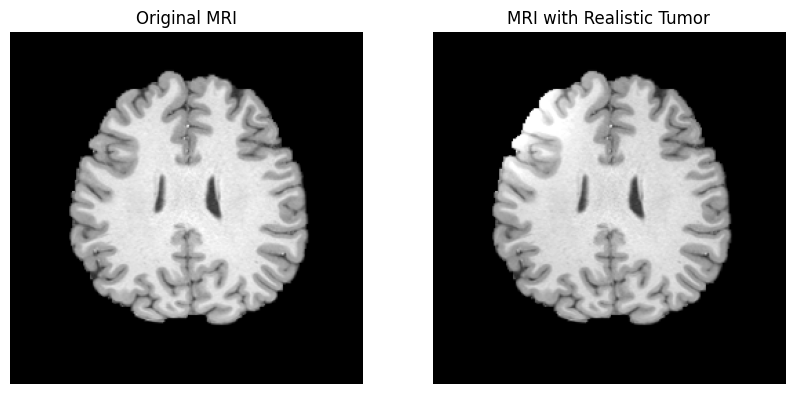

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import gaussian_filter

def generate_perlin_noise(shape, scale=10):
    """
    Generates Perlin-like noise for more realistic, irregular tumor structures.
    """
    noise = np.random.rand(*shape)
    return gaussian_filter(noise, sigma=scale)

def add_realistic_tumor(image, side="right", size=30, intensity=2):
    """
    Adds a small, irregular tumor with defined edges and realistic texture to the MRI.

    Args:
        image (numpy array): The grayscale MRI brain image.
        side (str): 'left' or 'right' to control tumor placement.
        size (int): Tumor size (affects spread).
        intensity (float): Brightness factor for tumor contrast.

    Returns:
        numpy array: Image with a realistic tumor.
    """
    img_with_tumor = image.copy()
    h, w = image.shape

    # Define tumor location (left or right side)
    if side == "left":
        center = (w // 10, h // 10 + 10)  # Slightly off-center
    else:
        center = (w // 12, h // 2 - 10)

    # Create an irregular tumor mask using Perlin-like noise
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    tumor_mask = np.exp(-(((x - center[0])**2 / (2 * (size**2))) + ((y - center[1])**2 / (2 * (size**2)))))

    # Add Perlin noise for texture
    noise = generate_perlin_noise(image.shape, scale=5)
    tumor_mask *= (1 + noise * 1)  # Blend Perlin noise with tumor shape

    # Apply Gaussian blur for smooth edges but keep some definition
    tumor_mask = cv2.GaussianBlur(tumor_mask, (15, 15), 3)

    # Introduce a darker ring around the tumor for a realistic boundary effect
    edge_mask = gaussian_filter(tumor_mask, sigma=3) - gaussian_filter(tumor_mask, sigma=7)
    edge_mask = np.clip(edge_mask * 3, 0, 1)  # Enhance edge contrast

    # Blend tumor into the image with localized shading
    img_with_tumor = np.clip(image + (intensity * tumor_mask * (image > 0.2)) - edge_mask * 0.5, 0, 1)

    return img_with_tumor

# Load and process the original MRI image
original_image = recovered_images[0]  # Replace with actual image array

# Generate tumor on the left side
tumor_image = add_realistic_tumor(original_image, side="left", size=35, intensity=1.1)

# Display Original vs Tumor MRI
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(tumor_image, cmap='gray')
axes[1].set_title("MRI with Realistic Tumor")
axes[1].axis('off')

plt.show()

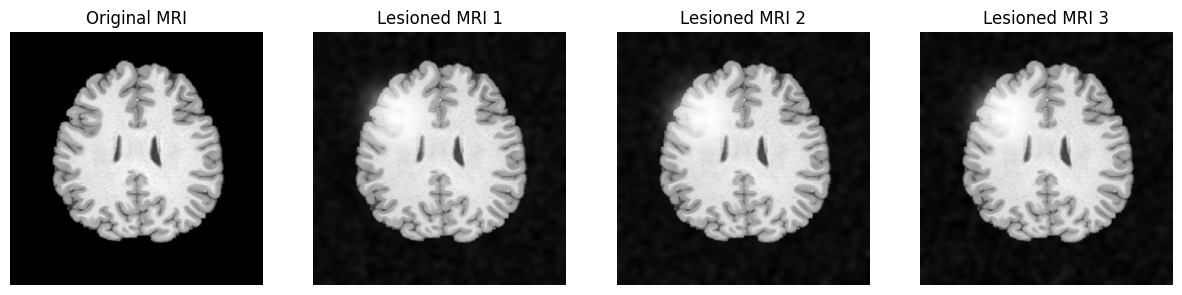

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

def random_center(shape):
    """
    Generates a random center for the lesion within the brain area (avoiding the skull).
    """
    h, w = shape
    x = random.randint(w // 3, 1 * w // 3)  # Keep lesion in brain area
    y = random.randint(h // 3, 1 * h // 3)  # Avoid extreme edges
    return (x, y)

def add_realistic_lesion(image, center=None, size=20, intensity=1.0):
    """
    Adds a realistic, irregular lesion to the brain in the MRI image.

    Args:
        image (numpy array): The MRI brain image.
        center (tuple): (x, y) coordinates of the lesion center.
        size (int): Approximate lesion size.
        intensity (float): Intensity factor for the lesion.

    Returns:
        numpy array: Image with a realistic lesion.
    """
    img_with_lesion = image.copy()
    h, w = image.shape

    # Define lesion center
    if center is None:
        center = random_center((h, w))  # Random position inside the brain

    # Create a Gaussian-shaped lesion mask
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    lesion_mask = np.exp(-((x - center[0])**2 + (y - center[1])**2) / (2 * (size ** 2)))

    # Add irregularities to the lesion using noise
    noise = np.random.normal(0, 0.2, image.shape)  # Gaussian noise for texture
    lesion_mask += noise
    lesion_mask = np.clip(lesion_mask, 0, 1)  # Normalize mask

    # Smooth the lesion for a more natural look
    lesion_mask = cv2.GaussianBlur(lesion_mask, (11, 11), 3)

    # Apply lesion only inside the brain (not the skull)
    img_with_lesion = np.clip(image * (1 - lesion_mask) + intensity * lesion_mask, 0, 1)

    return img_with_lesion

# Load and process the original MRI image
original_image = recovered_images[0]  # Replace with actual MRI image array

# Generate 3 different lesion images
lesioned_images = [add_realistic_lesion(original_image) for _ in range(3)]

# Display Original and Lesioned Images
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

for i, img in enumerate(lesioned_images):
    axes[i+1].imshow(img, cmap='gray')
    axes[i+1].set_title(f"Lesioned MRI {i+1}")
    axes[i+1].axis('off')

plt.show()


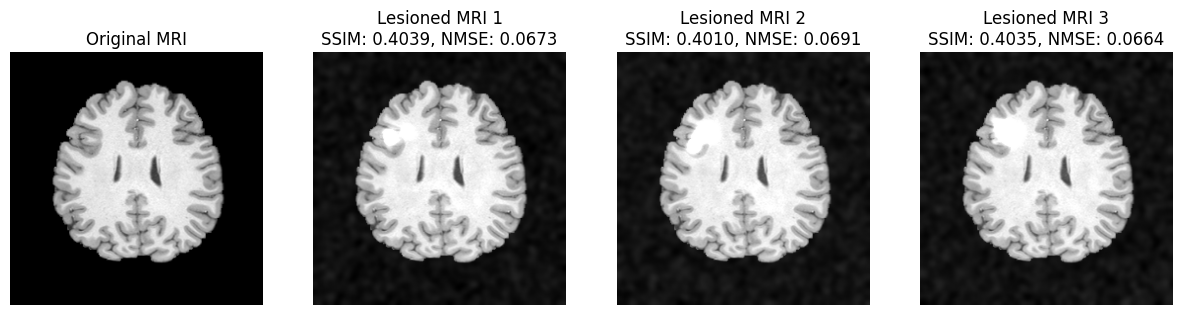

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Random lesion placement
def random_center(shape):
    h, w = shape
    x = random.randint(w // 3, 1 * w // 3)
    y = random.randint(h // 3, 1 * h // 3)
    return (x, y)

# Generate irregular lesion
def generate_realistic_lesion_mask(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    for _ in range(random.randint(4, 7)):
        radius = random.randint(max_radius // 3, max_radius)
        x, y = center[0] + random.randint(-10, 10), center[1] + random.randint(-10, 10)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)
    edema_mask = cv2.GaussianBlur(mask, (25, 25), 8) * 0.5
    mask = np.clip(mask + edema_mask, 0, 1)
    noise = np.random.normal(0, 0.1, (h, w))
    mask += noise
    mask = np.clip(mask, 0, 1)
    mask = cv2.GaussianBlur(mask, (13, 13), 3)
    return mask

# Apply lesion
def add_realistic_lesion(image, size_range=(3, 3), intensity=3.0):
    img_with_lesion = image.copy()
    h, w = image.shape
    center = random_center((h, w))
    size = random.randint(*size_range)
    lesion_mask = generate_realistic_lesion_mask(image.shape, center, size)
    img_with_lesion = np.clip(image * (1 - lesion_mask) + intensity * lesion_mask, 0, 1)
    return img_with_lesion

# Structural Similarity and NMSE computation
def compute_quality_metrics(original, reconstructed):
    nmse = np.mean((original - reconstructed) ** 2) / np.mean(original ** 2)
    ssim_value = ssim(original, reconstructed, data_range=original.max() - original.min())
    return nmse, ssim_value

# Load original MRI
original_image = recovered_images[0]

# Generate lesioned images
lesioned_images = [add_realistic_lesion(original_image) for _ in range(3)]

# Compute quality metrics
nmse_values, ssim_values = [], []
for img in lesioned_images:
    nmse, ssim_value = compute_quality_metrics(original_image, img)
    nmse_values.append(nmse)
    ssim_values.append(ssim_value)

# Display results
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

for i, img in enumerate(lesioned_images):
    axes[i+1].imshow(img, cmap='gray')
    axes[i+1].set_title(f"Lesioned MRI {i+1}\nSSIM: {ssim_values[i]:.4f}, NMSE: {nmse_values[i]:.4f}")
    axes[i+1].axis('off')

plt.show()

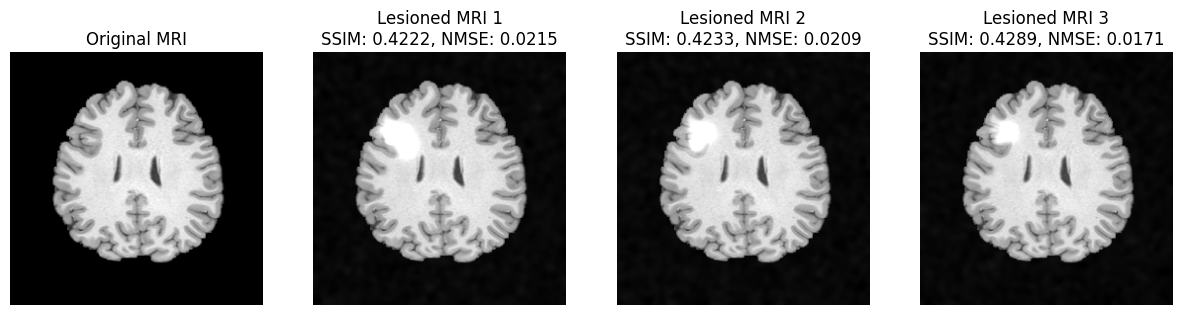

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Random lesion placement
def random_center(shape):
    h, w = shape
    x = random.randint(w // 3, 1 * w // 3)
    y = random.randint(h // 3, 1 * h // 3)
    return (x, y)

# Generate irregular lesion
def generate_realistic_lesion_mask(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    for _ in range(random.randint(4, 7)):
        radius = random.randint(max_radius // 3, max_radius)
        x, y = center[0] + random.randint(-10, 10), center[1] + random.randint(-10, 10)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)
    edema_mask = cv2.GaussianBlur(mask, (25, 25), 8) * 0.5
    mask = np.clip(mask + edema_mask, 0, 1)
    noise = np.random.normal(0, 0.1, (h, w))
    mask += noise
    mask = np.clip(mask, 0, 1)
    mask = cv2.GaussianBlur(mask, (13, 13), 3)
    return mask

# Apply lesion
def add_realistic_lesion(image, size_range=(7, 7), intensity=1.5):
    img_with_lesion = image.copy()
    h, w = image.shape
    center = random_center((h, w))
    size = random.randint(*size_range)
    lesion_mask = generate_realistic_lesion_mask(image.shape, center, size)
    img_with_lesion = np.clip(image * (1 - lesion_mask) + intensity * lesion_mask, 0, 1)
    return img_with_lesion

# Structural Similarity and NMSE computation
def compute_quality_metrics(original, reconstructed):
    nmse = np.mean((original - reconstructed) ** 2) / np.mean(original ** 2)
    ssim_value = ssim(original, reconstructed, data_range=original.max() - original.min())
    return nmse, ssim_value

# Load original MRI
original_image = recovered_images[0]

# Generate lesioned images
lesioned_images = [add_realistic_lesion(original_image) for _ in range(3)]

# Compute quality metrics
nmse_values, ssim_values = [], []
for img in lesioned_images:
    nmse, ssim_value = compute_quality_metrics(original_image, img)
    nmse_values.append(nmse)
    ssim_values.append(ssim_value)

# Display results
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

for i, img in enumerate(lesioned_images):
    axes[i+1].imshow(img, cmap='gray')
    axes[i+1].set_title(f"Lesioned MRI {i+1}\nSSIM: {ssim_values[i]:.4f}, NMSE: {nmse_values[i]:.4f}")
    axes[i+1].axis('off')

plt.show()

**Prof Picked The below**

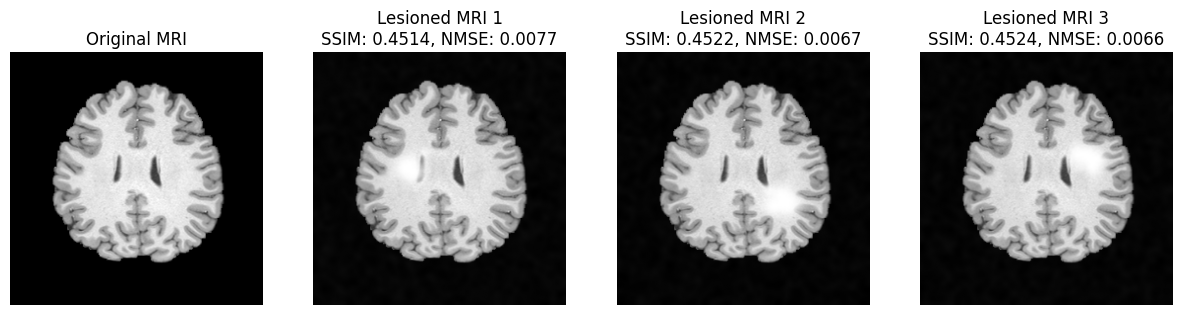

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Random lesion placement
def random_center(shape):
    h, w = shape
    x = random.randint(w // 3, 2 * w // 3)
    y = random.randint(h // 3, 2 * h // 3)
    return (x, y)

# Generate irregular lesion
def generate_realistic_lesion_mask(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    for _ in range(random.randint(4, 7)):
        radius = random.randint(max_radius // 3, max_radius)
        x, y = center[0] + random.randint(-10, 10), center[1] + random.randint(-10, 10)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)
    edema_mask = cv2.GaussianBlur(mask, (25, 25), 8) * 0.5
    mask = np.clip(mask + edema_mask, 0, 1)
    noise = np.random.normal(0, 0.1, (h, w))
    mask += noise
    mask = np.clip(mask, 0, 1)
    mask = cv2.GaussianBlur(mask, (13, 13), 3)
    return mask

# Apply lesion
def add_realistic_lesion(image, size_range=(8, 8), intensity=1.0):
    img_with_lesion = image.copy()
    h, w = image.shape
    center = random_center((h, w))
    size = random.randint(*size_range)
    lesion_mask = generate_realistic_lesion_mask(image.shape, center, size)
    img_with_lesion = np.clip(image * (1 - lesion_mask) + intensity * lesion_mask, 0, 1)
    return img_with_lesion

# Structural Similarity and NMSE computation
def compute_quality_metrics(original, reconstructed):
    nmse = np.mean((original - reconstructed) ** 2) / np.mean(original ** 2)
    ssim_value = ssim(original, reconstructed, data_range=original.max() - original.min())
    return nmse, ssim_value

# Load original MRI
original_image = recovered_images[0]

# Generate lesioned images
lesioned_images = [add_realistic_lesion(original_image) for _ in range(3)]

# Compute quality metrics
nmse_values, ssim_values = [], []
for img in lesioned_images:
    nmse, ssim_value = compute_quality_metrics(original_image, img)
    nmse_values.append(nmse)
    ssim_values.append(ssim_value)

# Display results
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

for i, img in enumerate(lesioned_images):
    axes[i+1].imshow(img, cmap='gray')
    axes[i+1].set_title(f"Lesioned MRI {i+1}\nSSIM: {ssim_values[i]:.4f}, NMSE: {nmse_values[i]:.4f}")
    axes[i+1].axis('off')

plt.show()

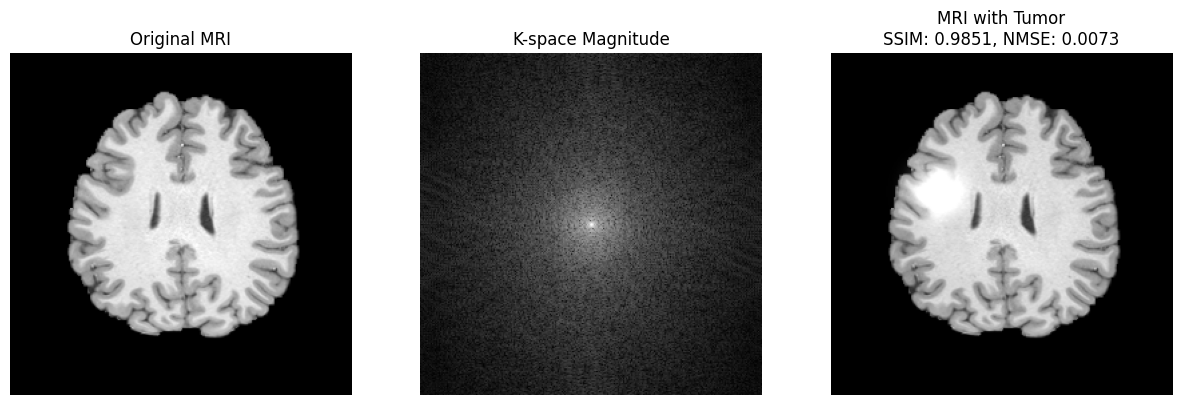

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI (assuming it's available as 'original_image')
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))

# Visualize K-space magnitude spectrum
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create a realistic tumor mask
def generate_realistic_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)

    # Fix range issue
    for _ in range(random.randint(1, 15)):  # Ensure valid loop range
        radius = random.randint(max(2, max_radius // 3), max_radius)  # Avoid zero or negative radius
        x, y = center[0] + random.randint(-5, 5), center[1] + random.randint(-5, 5)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    edema_mask = cv2.GaussianBlur(mask, (25, 25), 10) * 0.6
    mask = np.clip(mask + edema_mask, 0, 1)
    mask = cv2.GaussianBlur(mask, (15, 15), 5)
    return mask

# Function to add a tumor directly in spatial domain
def add_tumor_in_spatial(image, intensity=1.2):
    h, w = image.shape

    # Ensure the center selection is within valid range
    center = (random.randint(max(0, w // 4), min(w - 1, 3 * w // 1)),
              random.randint(max(0, h // 4), min(h - 1, 3 * h // 3)))

    max_radius = random.randint(3, min(15, min(h, w) // 4))  # Ensure max_radius is within image bounds
    tumor_mask = generate_realistic_tumor(image.shape, center, max_radius)

    modified_image = np.clip(image * (1 - tumor_mask) + intensity * tumor_mask, 0, 1)
    return modified_image

# Apply realistic tumor in spatial domain
modified_mri = add_tumor_in_spatial(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"MRI with Tumor\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


**Summary of the selected method**

| Feature | Method used |
|---|---|
| Fourier transform | `np.fft.fft2()`, `np.fft.fftshift()` |
| K-space visualisation | `np.log1p(np.abs(k_space))` |
| Tumour generation | Gaussian blobs (`np.exp(-distance^2 / 2σ^2)`) |
| Spatial blending | `image * (1 - tumor_mask) + intensity * tumor_mask` |
| Blurring for realism | `cv2.GaussianBlur()` |
| Image quality metrics | SSIM, NMSE |
| Plotting | `matplotlib.pyplot` |

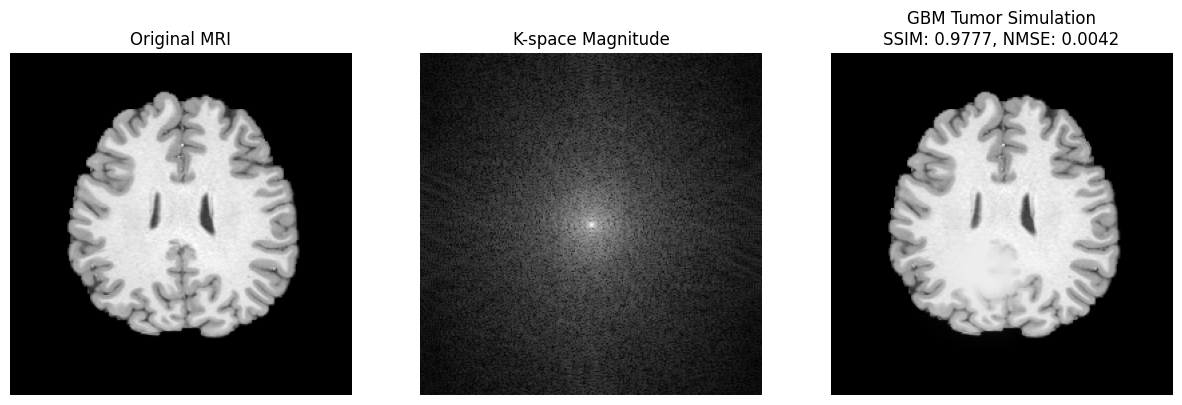

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create a more realistic GBM tumor with necrosis & edema
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)

    # Creating an irregular GBM lesion with multiple overlapping regions
    for _ in range(random.randint(6, 12)):
        radius = random.randint(max(5, max_radius // 3), max_radius)
        x, y = center[0] + random.randint(-5, 5), center[1] + random.randint(-5, 5)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # Adding **necrosis** (dark center) by reducing intensity at the core
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 3) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 0.5)
    mask -= necrosis_mask  # Make the center darker

    # Adding **peritumoral edema** (blurry surrounding area)
    edema_mask = cv2.GaussianBlur(mask, (27, 27), 10) * 0.5
    mask = np.clip(mask + edema_mask, 0, 1)

    # **Final smoothing** to avoid sharp bright spots
    mask = cv2.GaussianBlur(mask, (15, 15), 5)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=1.1):
    h, w = image.shape

    # Choose a random center for the tumor within valid brain areas
    center = (random.randint(w // 4, 3 * w // 4), random.randint(h // 4, 3 * h // 4))
    max_radius = random.randint(12, min(30, min(h, w) // 5))

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Adding slight **mass effect** (shifting pixels slightly)
    shift_x, shift_y = random.randint(-2, 2), random.randint(-2, 2)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # Blend GBM lesion into the MRI without making it too bright
    modified_image = np.clip(image * (1 - mass_effect) + intensity * (mass_effect * 0.8), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()

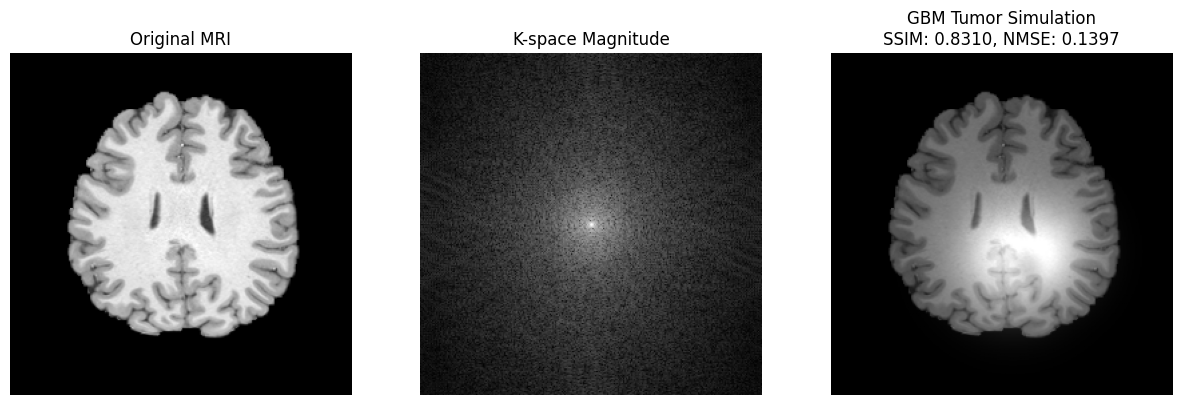

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI (assuming it's available as 'original_image')
original_image = recovered_images[0]

# Normalize image for consistency
original_image = (original_image - np.min(original_image)) / (np.max(original_image) - np.min(original_image))

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to generate a GBM-like tumor

def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)

    for _ in range(random.randint(3, 7)):  # Multiple irregular regions
        radius = random.randint(max_radius // 4, max_radius)  # Varying radius
        x, y = center[0] + random.randint(-10, 10), center[1] + random.randint(-10, 10)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # Adding necrotic core (darker region)
    necrosis = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 3) ** 2))
    necrosis = (necrosis > 0.5) * -0.3  # Darker center
    mask += necrosis

    # Blurring to mimic tumor infiltration
    mask = cv2.GaussianBlur(mask, (15, 15), 5)
    return mask

# Function to simulate GBM in spatial domain
def add_gbm_tumor(image, intensity=0.6):
    h, w = image.shape
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(20, min(h, w) // 4)  # Larger radius for GBM
    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Darkening the entire image
    modified_image = image * 0.5  # Make background darker

    # Adding tumor with slightly increased brightness
    modified_image = np.clip(modified_image + tumor_mask * intensity, 0, 1)

    return modified_image

# Apply GBM simulation
modified_mri = add_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()

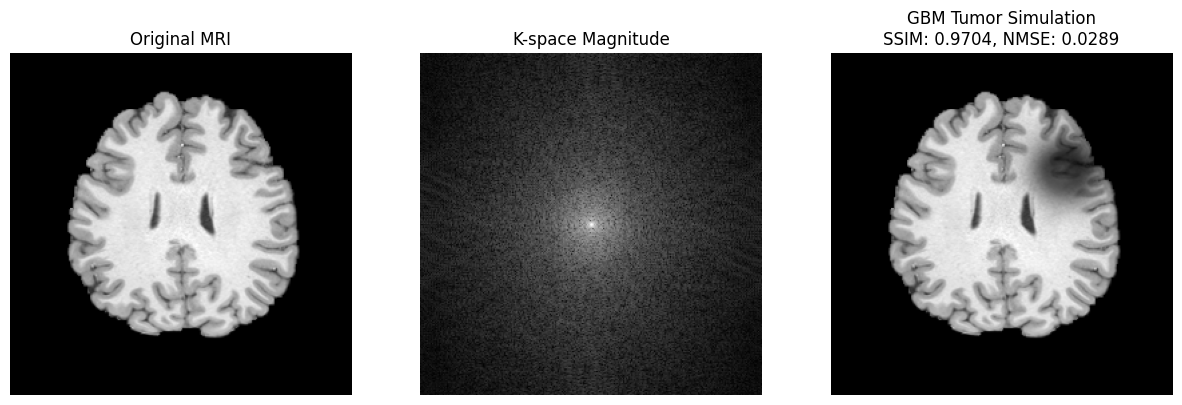

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create a more realistic GBM tumor with necrosis & edema
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)

    # Creating an irregular GBM lesion with multiple overlapping regions
    for _ in range(random.randint(6, 12)):
        radius = random.randint(max(5, max_radius // 3), max_radius)
        x, y = center[0] + random.randint(-5, 5), center[1] + random.randint(-5, 5)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # **Darker necrosis region**
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 3) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 0.5)
    mask -= necrosis_mask  # Make the center darker

    # **Edema around the tumor**
    edema_mask = cv2.GaussianBlur(mask, (27, 27), 10) * 0.3
    mask = np.clip(mask + edema_mask, 0, 1)

    # **Final smoothing** to make it blend naturally
    mask = cv2.GaussianBlur(mask, (15, 15), 5)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=0.8):  # Adjusted intensity to make pathology darker
    h, w = image.shape

    # Choose a random center for the tumor
    center = (random.randint(w // 4, 3 * w // 4), random.randint(h // 4, 3 * h // 4))
    max_radius = random.randint(12, min(30, min(h, w) // 5))

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # **Mass effect simulation** (slight pixel shifting)
    shift_x, shift_y = random.randint(-2, 2), random.randint(-2, 2)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # **Blend GBM lesion into the MRI, making it appear darker**
    modified_image = np.clip(image * (1 - 0.8 * mass_effect), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()

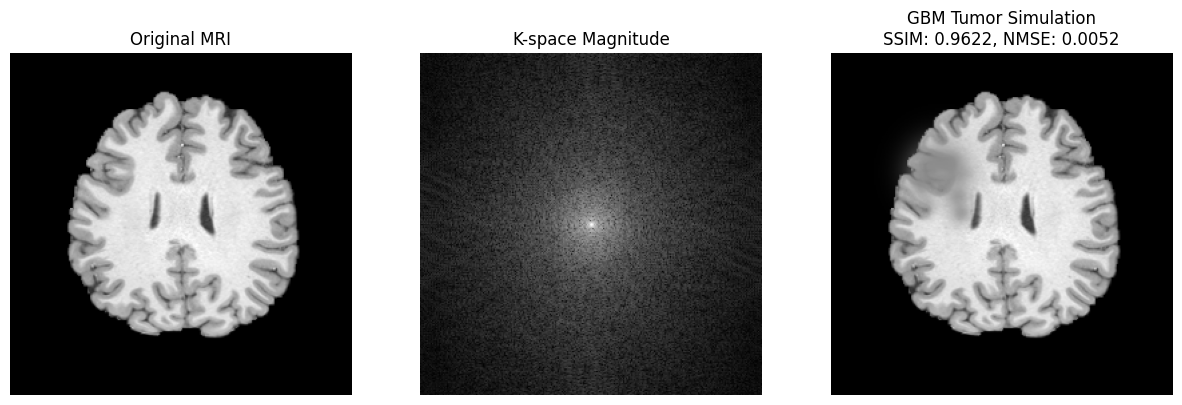

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create an irregular GBM tumor with invasive growth pattern
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    y_grid, x_grid = np.ogrid[:h, :w]

    # Create an irregular lobulated tumor shape with asymmetric edges
    for _ in range(random.randint(8, 14)):
        radius = random.randint(max(6, max_radius // 4), max_radius)
        x, y = center[0] + random.randint(-12, 12), center[1] + random.randint(-12, 12)
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # Add **finger-like infiltrations** extending from the tumor
    for _ in range(random.randint(4, 9)):
        ext_radius = random.randint(4, max_radius // 3)
        x, y = center[0] + random.randint(-20, 20), center[1] + random.randint(-20, 20)
        extension = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (ext_radius ** 2)))
        mask = np.maximum(mask, extension * random.uniform(0.5, 1.0))  # Randomize intensities

    # Add **necrotic center** (darker core)
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 2) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 0.4)
    mask -= necrosis_mask  # Subtract to make it darker in the middle

    # Add **peritumoral edema** (blurred swelling around the tumor)
    edema_mask = cv2.GaussianBlur(mask, (35, 35), 20) * 0.3
    mask = np.clip(mask + edema_mask, 0, 1)

    # Add **asymmetry** by distorting part of the tumor
    asymmetry_x = random.randint(-5, 5)
    asymmetry_y = random.randint(-5, 5)
    mask = np.roll(mask, shift=(asymmetry_x, asymmetry_y), axis=(0, 1))

    # Final smoothing to avoid harsh edges
    mask = cv2.GaussianBlur(mask, (11, 11), 4)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=1.05):
    h, w = image.shape

    # Choose a random center for the tumor in a brain region
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(15, min(35, min(h, w) // 4))

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Simulate **mild mass effect** (shifting brain tissue slightly)
    shift_x, shift_y = random.randint(-2, 2), random.randint(-2, 2)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # Darken the tumor **just slightly** for contrast
    modified_image = np.clip(image * (1 - mass_effect) + intensity * (mass_effect * 0.5), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


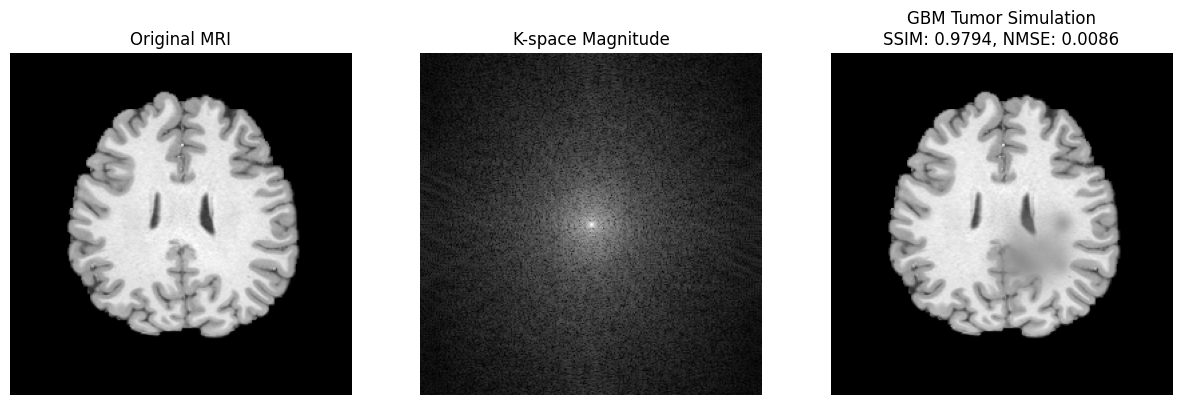

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create an irregular GBM tumor with invasive growth pattern
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    y_grid, x_grid = np.ogrid[:h, :w]

    # Create an irregular lobulated tumor shape with asymmetric edges
    for _ in range(random.randint(8, 14)):
        radius = random.randint(max(6, max_radius // 4), max_radius)
        x, y = center[0] + random.randint(-12, 12), center[1] + random.randint(-12, 12)
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # Add **finger-like infiltrations** extending from the tumor
    for _ in range(random.randint(4, 9)):
        ext_radius = random.randint(4, max_radius // 3)
        x, y = center[0] + random.randint(-20, 20), center[1] + random.randint(-20, 20)
        extension = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (ext_radius ** 2)))
        mask = np.maximum(mask, extension * random.uniform(0.5, 1.0))  # Randomize intensities

    # Add **necrotic center** (darker core)
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 2) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 0.4)
    mask -= necrosis_mask  # Subtract to make it darker in the middle

    # Add **peritumoral edema** (blurred swelling around the tumor)
    edema_mask = cv2.GaussianBlur(mask, (35, 35), 20) * 0.3
    mask = np.clip(mask + edema_mask, 0, 1)

    # Add **asymmetry** by distorting part of the tumor
    asymmetry_x = random.randint(-5, 5)
    asymmetry_y = random.randint(-5, 5)
    mask = np.roll(mask, shift=(asymmetry_x, asymmetry_y), axis=(0, 1))

    # Final smoothing to avoid harsh edges
    mask = cv2.GaussianBlur(mask, (11, 11), 4)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=1.05):
    h, w = image.shape

    # Choose a random center for the tumor in a brain region
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(15, min(35, min(h, w) // 4))

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Simulate **mild mass effect** (shifting brain tissue slightly)
    shift_x, shift_y = random.randint(-2, 2), random.randint(-2, 2)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # Darken the tumor **just slightly** for contrast
    modified_image = np.clip(image * (1 - mass_effect) + intensity * (mass_effect * 0.5), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


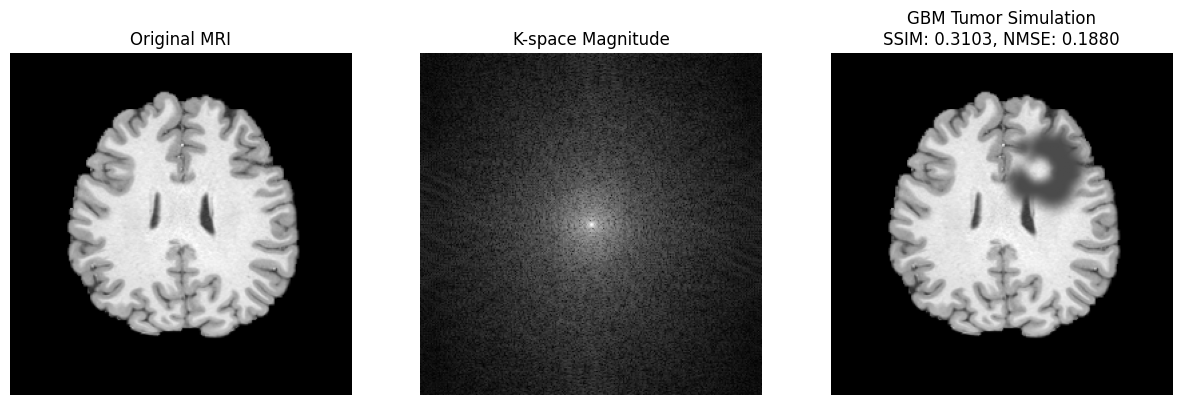

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create an aggressive GBM tumor with finger-like projections
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    y_grid, x_grid = np.ogrid[:h, :w]

    # **Intestine-like lobulated shape** with finger-like extensions
    for i in range(random.randint(5, 12)):
        radius = random.randint(max(5, max_radius // 6), max_radius)
        angle = i * (np.pi / random.uniform(2, 3))  # Spiral effect
        x = int(center[0] + radius * np.cos(angle))
        y = int(center[1] + radius * np.sin(angle))
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # **More aggressive finger-like infiltrations**
    for _ in range(random.randint(6, 12)):
        ext_radius = random.randint(5, max_radius // 2)
        x, y = center[0] + random.randint(-18, 18), center[1] + random.randint(-18, 18)
        extension = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (ext_radius ** 2)))
        mask = np.maximum(mask, extension * random.uniform(0.6, 1.0))  # Varied intensity

    # **Dark necrotic core** (but not pitch black)
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 2.5) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 1)  # Ensures it’s darker than the brain, but not black
    mask -= necrosis_mask

    # **Peritumoral edema** (blurred swelling around tumor)
    edema_mask = cv2.GaussianBlur(mask, (31, 31), 15) * 0.3
    mask = np.clip(mask + edema_mask, 0, 1)

    # **Distort tumor shape further**
    asymmetry_x = random.randint(-6, 6)
    asymmetry_y = random.randint(-6, 6)
    mask = np.roll(mask, shift=(asymmetry_x, asymmetry_y), axis=(0, 1))

    # **Make the tumor darker but not as dark as the background**
    mask = np.clip(mask * 1, 0.5, 1)  # Ensures visibility with clear contrast

    # Final smoothing for a natural look
    mask = cv2.GaussianBlur(mask, (9, 9), 3)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=0.7):  # Darker intensity for visibility
    h, w = image.shape

    # Choose a random center **inside the brain region**
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(15, 30)  # Keep it small but visible

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Simulate **mild mass effect** (brain tissue shift)
    shift_x, shift_y = random.randint(-3, 3), random.randint(-3, 3)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # **Darken the tumor clearly against the brain but not too much**
    modified_image = np.clip(image * (1 - mass_effect) + intensity * (mass_effect * 0.4), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


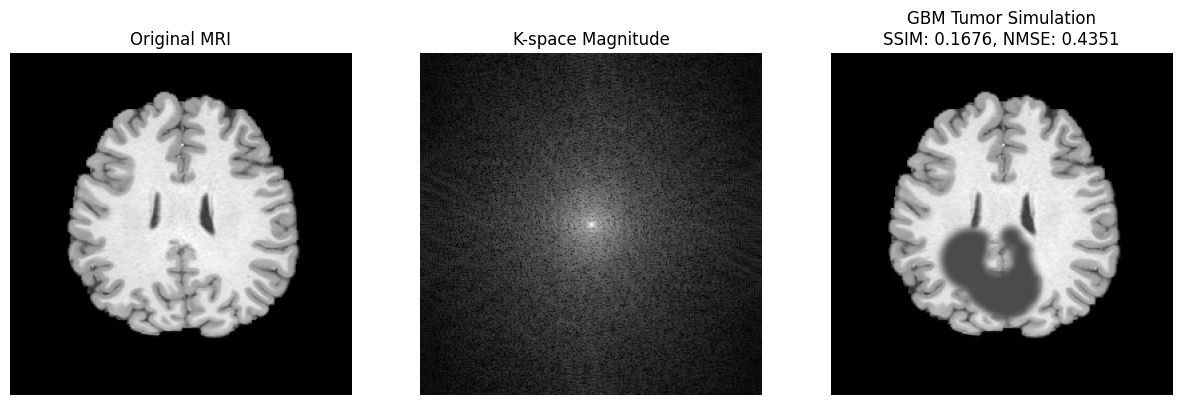

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create an aggressive GBM tumor with finger-like projections
def generate_gbm_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)
    y_grid, x_grid = np.ogrid[:h, :w]

    # **Intestine-like lobulated shape** with finger-like extensions
    for i in range(random.randint(5, 12)):
        radius = random.randint(max(5, max_radius // 6), max_radius)
        angle = i * (np.pi / random.uniform(2, 3))  # Spiral effect
        x = int(center[0] + radius * np.cos(angle))
        y = int(center[1] + radius * np.sin(angle))
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    # **More aggressive finger-like infiltrations**
    for _ in range(random.randint(6, 12)):
        ext_radius = random.randint(5, max_radius // 2)
        x, y = center[0] + random.randint(-18, 18), center[1] + random.randint(-18, 18)
        extension = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (ext_radius ** 2)))
        mask = np.maximum(mask, extension * random.uniform(0.6, 1.0))  # Varied intensity

    # **Dark necrotic core** (but not pitch black)
    necrosis_mask = np.exp(-((x_grid - center[0]) ** 2 + (y_grid - center[1]) ** 2) / (2 * (max_radius // 2.5) ** 2))
    necrosis_mask = np.clip(necrosis_mask, 0, 1)  # Ensures it’s darker than the brain, but not black
    mask -= necrosis_mask

    # **Peritumoral edema** (blurred swelling around tumor)
    edema_mask = cv2.GaussianBlur(mask, (31, 31), 15) * 0.3
    mask = np.clip(mask + edema_mask, 0, 1)

    # **Distort tumor shape further**
    asymmetry_x = random.randint(-6, 6)
    asymmetry_y = random.randint(-6, 6)
    mask = np.roll(mask, shift=(asymmetry_x, asymmetry_y), axis=(0, 1))

    # **Make the tumor darker but not as dark as the background**
    mask = np.clip(mask * 1.4, 0.8, 1)  # Ensures visibility with clear contrast

    # Final smoothing for a natural look
    mask = cv2.GaussianBlur(mask, (9, 9), 3)

    return mask

# Function to apply the GBM tumor to the MRI
def apply_gbm_tumor(image, intensity=0.7):  # Darker intensity for visibility
    h, w = image.shape

    # Choose a random center **inside the brain region**
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(15, 30)  # Keep it small but visible

    tumor_mask = generate_gbm_tumor(image.shape, center, max_radius)

    # Simulate **mild mass effect** (brain tissue shift)
    shift_x, shift_y = random.randint(-3, 3), random.randint(-3, 3)
    mass_effect = np.roll(tumor_mask, shift=(shift_x, shift_y), axis=(0, 1))

    # **Darken the tumor clearly against the brain but not too much**
    modified_image = np.clip(image * (1 - mass_effect) + intensity * (mass_effect * 0.4), 0, 1)

    return modified_image

# Apply the GBM tumor to the MRI
modified_mri = apply_gbm_tumor(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"GBM Tumor Simulation\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


**PERLIN NOISE INSTEAD OF GAUSSIAN**

In [ ]:
!pip install noise

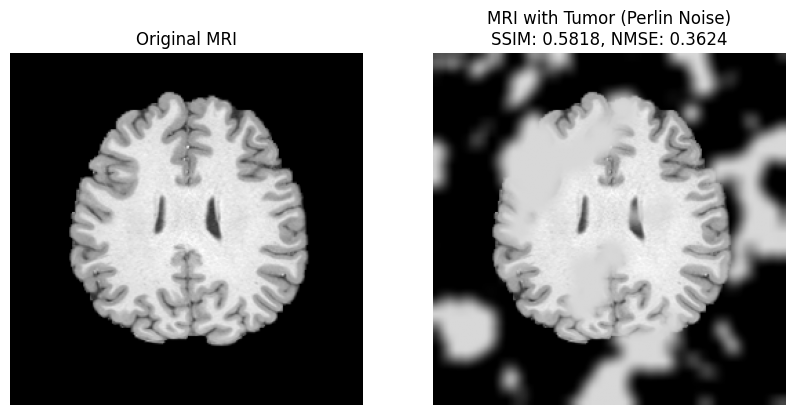

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import noise
from skimage.metrics import structural_similarity as ssim

# Function to generate Perlin noise
def generate_perlin_noise(shape, scale=30):
    h, w = shape
    perlin_noise = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            perlin_noise[i][j] = noise.pnoise2(i / scale, j / scale, octaves=6)
    perlin_noise = (perlin_noise - perlin_noise.min()) / (perlin_noise.max() - perlin_noise.min())
    return perlin_noise

# Generate irregular tumor mask using Perlin noise
def generate_realistic_tumor_perlin(shape, center, threshold=0.6):
    perlin_noise = generate_perlin_noise(shape, scale=50)
    tumor_mask = (perlin_noise > threshold).astype(np.float32)
    tumor_mask = cv2.GaussianBlur(tumor_mask, (15, 15), 5)  # Slight smoothing
    return tumor_mask

# Apply tumor to MRI
def add_tumor_perlin(image):
    img_with_tumor = image.copy()
    tumor_mask = generate_realistic_tumor_perlin(image.shape, center=None)
    img_with_tumor = np.clip(image * (1 - tumor_mask) + 0.8 * tumor_mask, 0, 1)
    return img_with_tumor

# Load original MRI
original_image = recovered_images[0]

# Generate tumor-modified MRI
modified_mri = add_tumor_perlin(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(modified_mri, cmap='gray')
axes[1].set_title(f"MRI with Tumor (Perlin Noise)\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[1].axis('off')

plt.show()


*Bayesian Tumor Generation*

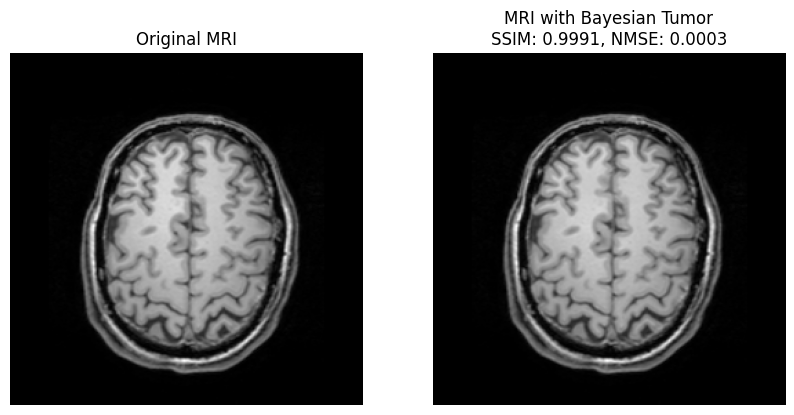

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import scipy.stats as stats
from skimage.metrics import structural_similarity as ssim

# Bayesian sampling for tumor properties
def sample_tumor_parameters():
    radius = np.random.normal(loc=12, scale=4)  # Mean radius = 12, std = 4
    intensity = np.random.beta(2, 5)  # Beta distribution for contrast variation
    return max(5, int(radius)), intensity

# Generate Bayesian tumor mask
def generate_bayesian_tumor(shape, center):
    h, w = shape
    radius, intensity = sample_tumor_parameters()
    tumor_mask = np.zeros((h, w), dtype=np.float32)
    x, y = center
    y_grid, x_grid = np.ogrid[:h, :w]
    tumor = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
    tumor_mask = np.clip(tumor * intensity, 0, 1)
    return tumor_mask

# Apply Bayesian tumor to MRI
def add_tumor_bayesian(image):
    img_with_tumor = image.copy()
    h, w = image.shape
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    tumor_mask = generate_bayesian_tumor(image.shape, center)
    img_with_tumor = np.clip(image * (1 - tumor_mask) + 0.7 * tumor_mask, 0, 1)
    return img_with_tumor

# Load original MRI
original_image = recovered_images[0]

# Generate tumor-modified MRI using Bayesian sampling
bayesian_mri = add_tumor_bayesian(original_image)

# Compute quality metrics
nmse_value = np.mean((original_image - bayesian_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, bayesian_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(bayesian_mri, cmap='gray')
axes[1].set_title(f"MRI with Bayesian Tumor\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[1].axis('off')

plt.show()

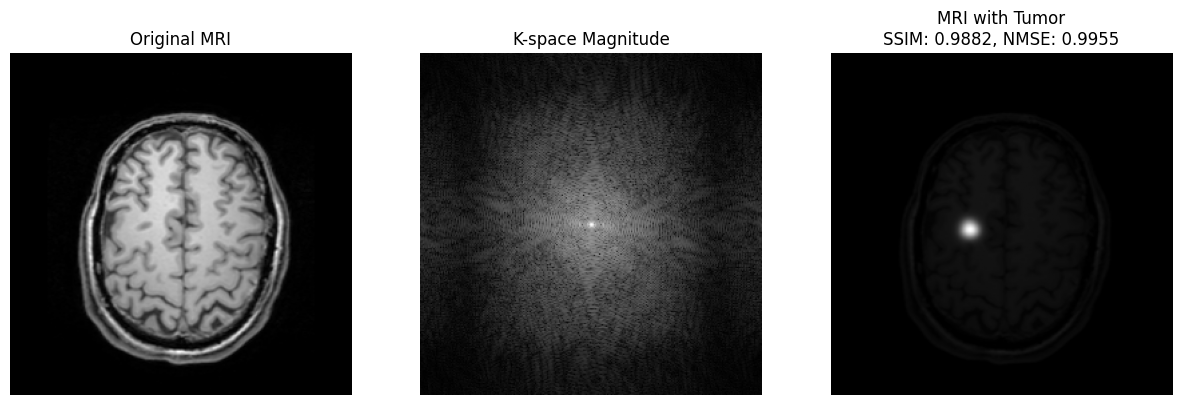

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI (assuming it's available as 'original_image')
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))

# Visualize K-space magnitude spectrum
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to create a smaller, more realistic tumor mask
def generate_realistic_tumor(shape, center, max_radius):
    h, w = shape
    mask = np.zeros((h, w), dtype=np.float32)

    for _ in range(random.randint(3, 6)):
        radius = random.randint(max_radius // 4, max_radius // 2)
        x, y = center[0] + random.randint(-3, 3), center[1] + random.randint(-3, 3)
        y_grid, x_grid = np.ogrid[:h, :w]
        lesion = np.exp(-((x_grid - x) ** 2 + (y_grid - y) ** 2) / (2 * (radius ** 2)))
        mask = np.maximum(mask, lesion)

    edema_mask = cv2.GaussianBlur(mask, (15, 15), 5) * 0.5
    mask = np.clip(mask + edema_mask, 0, 1)
    mask = cv2.GaussianBlur(mask, (9, 9), 3)
    return mask

# Function to add tumor in K-space
def add_tumor_in_kspace(k_space, image_shape, intensity=10.0):
    h, w = k_space.shape
    center = (random.randint(w // 3, 2 * w // 3), random.randint(h // 3, 2 * h // 3))
    max_radius = random.randint(8, 15)  # Smaller tumor size
    tumor_mask = generate_realistic_tumor(image_shape, center, max_radius)

    tumor_kspace = np.fft.fftshift(np.fft.fft2(tumor_mask))
    k_space += intensity * tumor_kspace
    return k_space

# Modify K-space with a smaller, realistic tumor
k_space_tumor = add_tumor_in_kspace(k_space.copy(), original_image.shape)

# Inverse Fourier Transform to get back the modified MRI
modified_mri = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space_tumor)))

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"MRI with Tumor\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


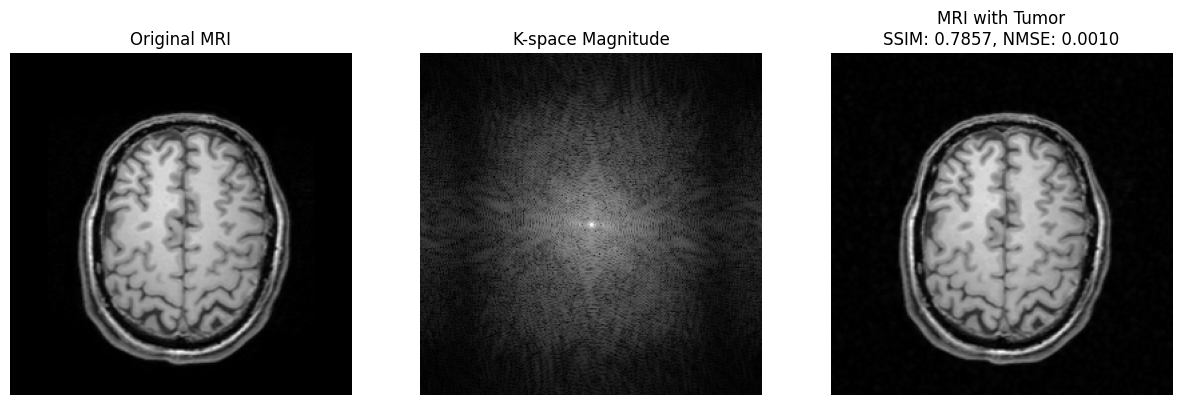

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.metrics import structural_similarity as ssim

# Load original MRI (assuming it's available as 'original_image')
original_image = recovered_images[0]

# Perform 2D Fourier Transform to get K-space
k_space = np.fft.fftshift(np.fft.fft2(original_image))

# Visualize K-space magnitude spectrum
k_space_magnitude = np.log1p(np.abs(k_space))

# Function to add a structured tumor in K-space
def add_tumor_in_kspace(k_space, center_fraction=0.15, intensity=10.0):
    h, w = k_space.shape
    center_x, center_y = h // 2, w // 2
    radius = int(min(h, w) * center_fraction)

    y, x = np.ogrid[:h, :w]
    mask = ((x - center_x)**2 + (y - center_y)**2) <= radius**2

    tumor_pattern = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * (radius ** 2)))
    k_space[mask] += intensity * tumor_pattern[mask] * (np.random.randn(*k_space[mask].shape) + 1j * np.random.randn(*k_space[mask].shape))
    return k_space

# Modify K-space with tumor
k_space_tumor = add_tumor_in_kspace(k_space.copy())

# Inverse Fourier Transform to get back the modified MRI
modified_mri = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space_tumor)))

# Compute quality metrics
nmse_value = np.mean((original_image - modified_mri) ** 2) / np.mean(original_image ** 2)
ssim_value = ssim(original_image, modified_mri, data_range=original_image.max() - original_image.min())

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(k_space_magnitude, cmap='gray')
axes[1].set_title("K-space Magnitude")
axes[1].axis('off')

axes[2].imshow(modified_mri, cmap='gray')
axes[2].set_title(f"MRI with Tumor\nSSIM: {ssim_value:.4f}, NMSE: {nmse_value:.4f}")
axes[2].axis('off')

plt.show()


In [ ]:
import torch

realcov = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/realcov_L2_13-001.pt')
imagcov = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/imagcov_L2_13-002.pt')

realmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_realmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))
imagmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_imagmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))

realvar= torch.diagonal(realcov)
imagvar= torch.diagonal(imagcov)

magmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_magmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))

realmean = realmean/magmean
imagmean = imagmean/magmean

k-space Image Undersampled: Optimal Sampling Path Training
Here we only give the example to choose the optimal sampling path for a single image. The Final Optimal Sampling path is chosen based on the appearance frequency of all chosen ring's radii

In real practive, we saved all k-space image data in h5 file.

For illustration purpose, we also save the results and they can be loaded directly.

In [ ]:
load = False

if load == True:
  r_list = np.load('./Undersampled-Path/example_pattern.npy')
  errormag_list = np.load('./Undersampled-Path/example_meanr_error.npy')
  path = np.copy(r_list)
  err = np.copy(errormag_list)

else:
  round = 50
  sig = 1e-3

  r_list, errormag_list,error_whole = GPR_cir_nor(im_k,round,sig,mode = None)
  path = np.copy(r_list)
  err = np.copy(errormag_list)


round: 0 ,chosen r position: 0
round: 1 ,chosen r position: 1
round: 2 ,chosen r position: 3
round: 3 ,chosen r position: 9
round: 4 ,chosen r position: 6
round: 5 ,chosen r position: 15
round: 6 ,chosen r position: 12
round: 7 ,chosen r position: 20
round: 8 ,chosen r position: 2
round: 9 ,chosen r position: 25
round: 10 ,chosen r position: 17
round: 11 ,chosen r position: 30
round: 12 ,chosen r position: 22
round: 13 ,chosen r position: 7
round: 14 ,chosen r position: 35
round: 15 ,chosen r position: 27
round: 16 ,chosen r position: 4
round: 17 ,chosen r position: 41
round: 18 ,chosen r position: 32
round: 19 ,chosen r position: 47
round: 20 ,chosen r position: 10
round: 21 ,chosen r position: 38
round: 22 ,chosen r position: 53
round: 23 ,chosen r position: 14
round: 24 ,chosen r position: 44
round: 25 ,chosen r position: 5
round: 26 ,chosen r position: 59
round: 27 ,chosen r position: 19
round: 28 ,chosen r position: 50
round: 29 ,chosen r position: 65
round: 30 ,chosen r position:

In [ ]:
!pwd

/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src


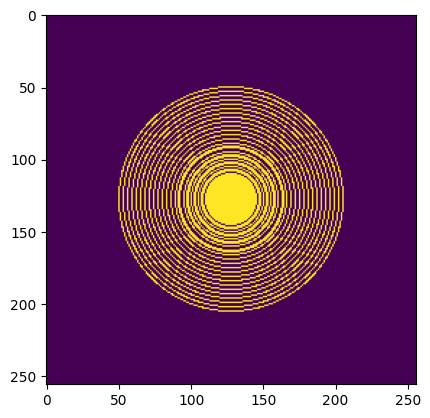

In [ ]:
n = 42
mask_r,mask_r_ratio= mask_of_r_order(imgsz-2*w,r_list[:n+1])
plt.imshow(mask_larger(256,48,mask_r))

The average k-space error magnitude $<\sigma>_r$ and the chosen ring position in each round of sampling is shown as:

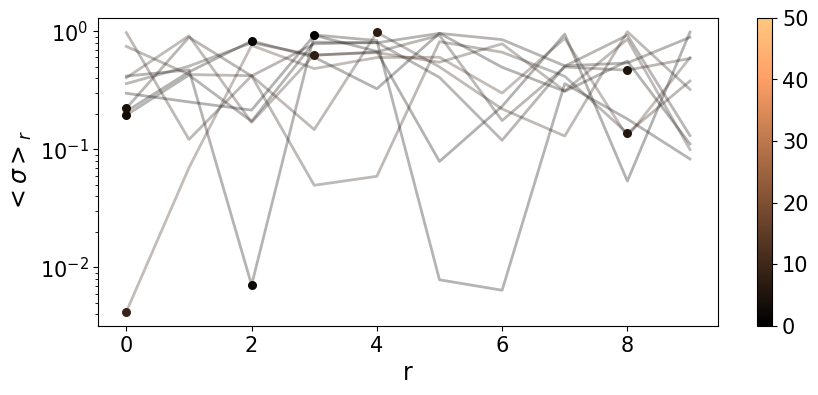

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as m
import numpy as np

sz = 15
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 4), gridspec_kw={'wspace': 0.2})

cm = plt.get_cmap('copper')
NUM_COLORS = 50
c = [cm(1.0 * i / NUM_COLORS) for i in range(NUM_COLORS)] * 2
plt.gca().set_prop_cycle(color=c)

plt.plot(err.T, linewidth=2, alpha=0.3, zorder=0)

plt.yscale('log')

plt.xticks(fontsize=sz)
plt.yticks(fontsize=sz)

plt.xlabel('r', fontsize=sz + 2)
plt.ylabel(r'$<\sigma>_r$', fontsize=sz + 2)

for i in range(n):
    plt.scatter(
        [int(x) for x in path[:n]][i],
        (err[[np.linspace(0, n - 1, n, dtype=int)], [int(x) for x in path[:n]]]).reshape((n, 1))[i],
        30,
        alpha=1,
        marker='o',
        zorder=1,
    )

# Fix: Ensure mappable is properly defined for colorbar
norm = m.colors.Normalize(vmin=0, vmax=NUM_COLORS)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])  # Dummy array for colorbar

cbar = fig.colorbar(sm, ax=axes)  # Attach colorbar to figure
cbar.ax.tick_params(labelsize=sz)


**k-space Image Undersampled: final optimal subsampling path**

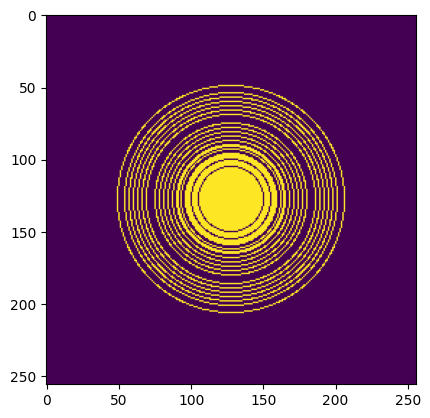

In [ ]:
L1L2_6822 = np.load('./Undersampled-Path/f2_6822_rpattern.npy')
mask_r,mask_r_ratio= mask_of_r_order(imgsz-2*w,L1L2_6822)
plt.imshow(mask_larger(256,48,mask_r))

**check the k-space zero-filled reconstructed image and quality.**

the zero-filled NMSE is: 0.025171350948293782
the zero-filled SSIM is: 0.49807705509632827
the zero-filled PSNR is: 28.973994808677965
----------------------------------------------------------------------------------------------------


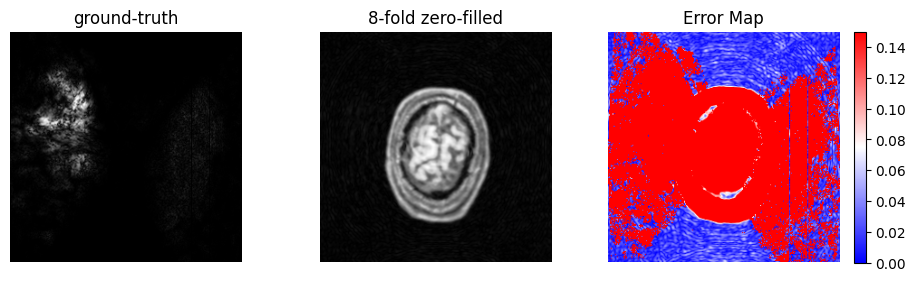

In [ ]:
ind = np.linspace(0,(imgsz-2*w)**2-1,(imgsz-2*w)**2,dtype = int)
rcon,nmse_,ssim_,psnr_ = zerofill_samp(im_k,ind[mask_r.view(-1) == 1])

print("the zero-filled NMSE is:",nmse_ )
print("the zero-filled SSIM is:",ssim_ )
print("the zero-filled PSNR is:",psnr_ )
print('--'*50)

fig,axes = plt.subplots(nrows = 1,ncols = 3, figsize = (12,3),gridspec_kw={'wspace':0.,'hspace':0.1})
axes[0].imshow(im[:,:,0],cmap='Greys_r')
axes[0].axis('off')
axes[0].set_title('ground-truth')
axes[1].imshow(rcon[:,:],cmap='Greys_r')
axes[1].axis('off')
axes[1].set_title('8-fold zero-filled')

fig2 = axes[2].imshow(abs(im[:,:,0]-rcon[:,:].numpy()),cmap='bwr',clim = [0,0.15])
axes[2].set_title('Error Map')
axes[2].axis('off')
fig.colorbar(fig2,ax = axes[2])

**Image Reconstruction: whole process**

In [ ]:
import torch

realcov = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/realcov_L2_13-001.pt')
imagcov = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/imagcov_L2_13-002.pt')

realmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_realmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))
imagmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_imagmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))

realvar= torch.diagonal(realcov)
imagvar= torch.diagonal(imagcov)

magmean = torch.load('/content/drive/MyDrive/DATICAN/MSC/Downloaded/trials/KspaceMRIBO-main/src/Boston_GPR_dictionary/train_magmean_6822.pt').reshape((imgsz-2*w,imgsz-2*w))

realmean = realmean/magmean
imagmean = imagmean/magmean

**Image Reconstruction using GPR and get the reconstruction results**

the BO NMSE is: 0.0036657910891859033
the BO SSIM is: 0.9198512491726876
the BO PSNR is: 37.34138208032472
----------------------------------------------------------------------------------------------------


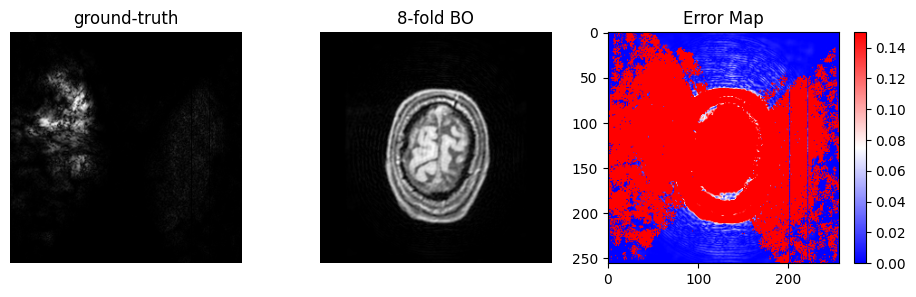

In [ ]:
lamb = 1e-3
rcon1,nmse_1,ssim_1,psnr_1 = bayesian_mean_samp_nor(im_k,ind[mask_r.view(-1) == 1],lamb)
print("the BO NMSE is:",nmse_1 )
print("the BO SSIM is:",ssim_1 )
print("the BO PSNR is:",psnr_1 )
print('--'*50)

fig,axes = plt.subplots(nrows = 1,ncols = 3, figsize = (12,3),gridspec_kw={'wspace':0.,'hspace':0.1})
axes[0].imshow(im[:,:,0],cmap='Greys_r')
axes[0].axis('off')
axes[0].set_title('ground-truth')
axes[1].imshow(rcon1[:,:],cmap='Greys_r')
axes[1].axis('off')
axes[1].set_title('8-fold BO')

fig2 = axes[2].imshow(abs(im[:,:,0]-rcon1[:,:].numpy()),cmap='bwr',clim = [0,0.15])
axes[2].set_title('Error Map')
axes[1].axis('off')
fig.colorbar(fig2,ax = axes[2])